### Locating the Project Root

In [1]:
import sys
from pathlib import Path


def find_project_root(start_directory: Path) -> Path:
    """
    Find the nearest Cats-vs-Dogs project root.

    Args:
        start_directory: Directory from which to begin the upward search.

    Returns:
        Path: Directory containing ``pyproject.toml`` and ``src/cats_dogs_mlops``.

    Raises:
        FileNotFoundError: If the notebook is executed outside the project tree.
    """

    resolved_start = start_directory.resolve()
    for candidate in (resolved_start, *resolved_start.parents):
        package_dir = candidate / "src" / "cats_dogs_mlops"
        if (candidate / "pyproject.toml").is_file() and package_dir.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Start Jupyter inside the repository."
    )


# This project's data is already fetched (`dvc repro download`), so there is no
# zip to download here -- this cell instead points the notebook at the project.
import os

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\PostGraduationProjects\MLOps-Cats-Dogs-Pipeline


### Preparing Output Directories

In [2]:
# No zip to extract -- create the local directory this notebook saves models to.
Path("artifacts/resnet50").mkdir(parents=True, exist_ok=True)

### Loading Project Configuration

In [3]:
import yaml

# Data is already downloaded and split by `dvc repro prepare` (deduplicated by
# content hash), so there is nothing to unzip -- load its location instead.
params_path = PROJECT_ROOT / "params.yaml"
with params_path.open("r", encoding="utf-8") as params_file:
    parameters = yaml.safe_load(params_file)

data_parameters = parameters["data"]
training_parameters = parameters["training"]

RAW_DATA_DIR = PROJECT_ROOT / data_parameters["raw_dir"]
PROCESSED_DATA_DIR = PROJECT_ROOT / data_parameters["processed_dir"]
IMAGE_SIZE = int(data_parameters["image_size"])
BATCH_SIZE = int(training_parameters["batch_size"])
NUM_WORKERS = int(training_parameters["num_workers"])

DATA_AVAILABLE = all(
    (PROCESSED_DATA_DIR / split).is_dir() for split in ("train", "validation", "test")
)
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Data available: {DATA_AVAILABLE}")
if not DATA_AVAILABLE:
    print("Run `dvc repro prepare` to create data/processed before running this notebook fully.")

Processed data directory: D:\PostGraduationProjects\MLOps-Cats-Dogs-Pipeline\data\processed
Data available: True


# Residual Networks (ResNet)

__ResNet__ or __Residual Neural Network__ was proposed by ([He et al.](https://arxiv.org/pdf/1512.03385.pdf)) researchers at Microsoft Research namely, _Kaiming He_, _Xiangyu Zhang_, _Shaoqing Ren_ and, _Jian Sun_; which allow us to train much deeper networks than were previously practically feasible. Also, ResNet won [ImageNet](https://www.image-net.org/about.php) Challenge in 2015.

<center>
    <img src="https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/MicrosoftResearch.png?raw=1" alt="Microsoft Research" width="500px"> <br>
</center>

## Problem with Very Deep Neural Networks
The main benefit of a very deep network is that it can represent very complex functions. It can also learn features at many different levels of abstraction, from edges (at the lower layers) to very complex features (at the deeper layers). However, using a deeper network doesn't always help. A huge barrier to training them is vanishing gradients: very deep networks often have a gradient signal that goes to zero quickly, thus making gradient descent unbearably slow. More specifically, during gradient descent, as you backprop from the final layer back to the first layer, you are multiplying by the weight matrix on each step, and thus the gradient can decrease exponentially quickly to zero (or, in rare cases, grow exponentially quickly and "explode" to take very large values).

During training, we might therefore see the magnitude (or norm) of the gradient for the earlier layers descrease to zero very rapidly as training proceeds:
![Vanishing Gradient](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/VanishingGradient.png?raw=1)
<center>
    <b><i>Figure 1:</i></b> <i>The speed of learning decreases very rapidly for the early layers as the network trains</i>
</center>

## Building a Residual Network
In ResNet architecture, a *“shortcut”* or a *“skip connection”* allows the gradient to be directly backpropagated to earlier layers:
![Skip Connection](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/SkipConnection.png?raw=1)
<center>
    <b><i>Figure 2:</i></b> <i>A ResNet block showing a skip-connection</i>
</center>

The image on the left shows the "main path" through the network. The image on the right adds a shortcut to the main path. By stacking these ResNet blocks on top of each other, you can form a very deep network.

We also saw in lecture that having ResNet blocks with the shortcut also makes it very easy for one of the blocks to learn an identity function. This means that you can stack on additional ResNet blocks with little risk of harming training set performance. (There is also some evidence that the ease of learning an identity function--even more than skip connections helping with vanishing gradients--accounts for ResNets' remarkable performance.)

Two main types of blocks are used in a ResNet, depending mainly on whether the input/output dimensions are same or different. We are going to implement both of them.

# ResNet-50 Implementation

## Importing Dependencies

In [4]:
# Import NumPy as our model trains on arrays which will be handled by NumPy
import numpy as np

# Import Random for reproducible seeding
import random

# Import mayplotlib and seaborn to visualize the metrics of our model
import matplotlib.pyplot as plt
import seaborn as sns

# Import Pillow for image loading (this project's convention -- see
# cats_dogs_mlops.preprocessing -- rather than OpenCV)
from PIL import Image

# Import OrderedDict so the head/model Sequential definitions below can name
# their layers (used but never imported in the original migration -- NameError)
from collections import OrderedDict

# Import scikit-learn metrics which will be used to display the metrics of the model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, auc, roc_curve

# Import PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# This project's own training/eval transforms, so augmentation and normalisation
# match scripts/train.py's baseline pipeline exactly.
from cats_dogs_mlops.preprocessing import build_evaluation_transform, build_training_transform

# Safety default: running this notebook top-to-bottom must not silently kick off
# a full 100-epoch ResNet-50-from-scratch training run. Flip to True deliberately.
RUN_TRAINING = True

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Used throughout below (`.to(device)`) but never defined in the original migration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.13.0+cu132
Device: cuda


## Dataset Overview

In [5]:
DATASET_PATH = RAW_DATA_DIR

In [6]:
# The Kaggle raw dataset nests class folders inconsistently across mirrors
# (e.g. training_set/training_set/cats), so images are found by matching the
# parent directory name -- see scripts/prepare_data.py's discover_class_images
# -- rather than a flat os.listdir(DATASET_PATH), which would miss nested layouts.
CLASS_ALIASES = {"cats": {"cat", "cats"}, "dogs": {"dog", "dogs"}}
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

Randomly display any image from each class of the dataset

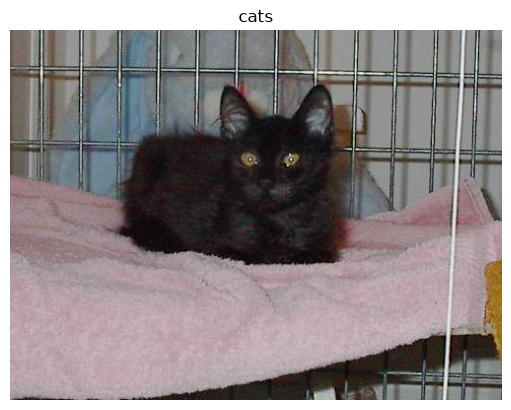

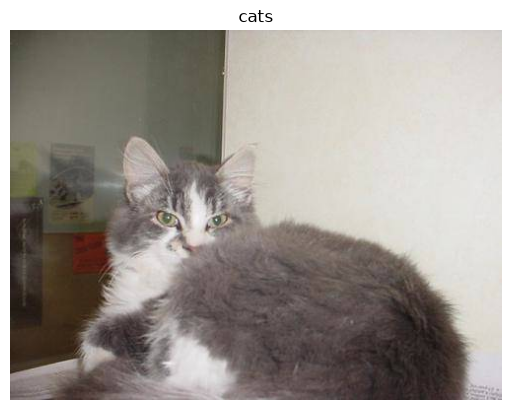

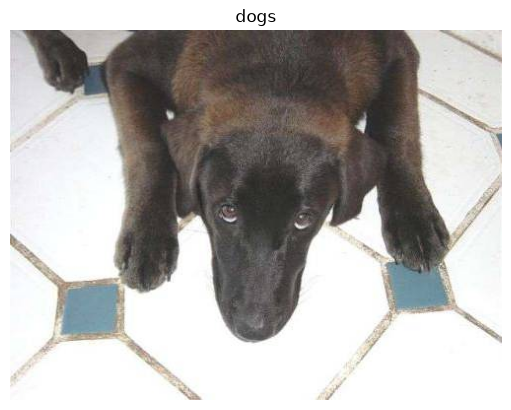

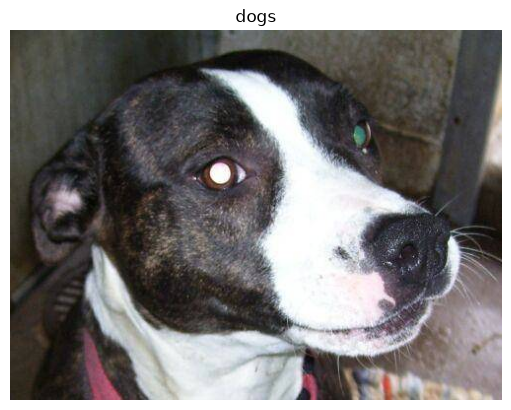

In [7]:
# picking a random image from each class of the dataset
for class_name, aliases in CLASS_ALIASES.items():
    class_images = [
        path
        for path in DATASET_PATH.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
        and path.parent.name.lower() in aliases
    ]
    for img_path in np.random.choice(class_images, size=2):
        # read each image with the help of Pillow
        image = Image.open(img_path)
        # plot the image using matplotlib
        plt.imshow(image); plt.axis("off")
        # give image a title using matplotlib
        plt.title(class_name)
        # show or display the image using matplotlib
        plt.show()

In [8]:
TRAIN_PATH = PROCESSED_DATA_DIR / "train"

In [9]:
TEST_PATH = PROCESSED_DATA_DIR / "test"

In [10]:
VALIDATE_PATH = PROCESSED_DATA_DIR / "validation"

## Preprocessing Images

**`build_training_transform()`** (`src/cats_dogs_mlops/preprocessing.py`) applies data augmentation to every training image via `torchvision.transforms`. Augmentation means the same image is seen slightly differently each epoch, which increases the effective diversity of the training set without acquiring new images.
Augmentations applied here:
- *RandomResizedCrop(scale=(0.80, 1.0)):* crop a random 80-100% region, then resize to the target size.
- *RandomHorizontalFlip(p=0.5):* flip left-right half the time.
- *ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10):* small random colour perturbations.

Validation, test, and inference use `build_evaluation_transform()` instead -- deterministic resize only, no randomness, so evaluation numbers are reproducible.

In [19]:
# The original ImageDataGenerator/flow_from_directory calls belong entirely to
# Keras and don't apply to a PyTorch model -- they yield NumPy batches (no
# .to(device) support) and, more importantly, loop *infinitely* when driven by a
# plain `for` loop (they're designed for `steps_per_epoch`-bounded model.fit(),
# not a manual loop), which is why the training loop below used to hang on its
# first epoch. build_training_transform/build_evaluation_transform (this
# project's own augmentation/normalisation, matching scripts/train.py) plus
# torchvision's ImageFolder + DataLoader are the direct PyTorch equivalent.
if DATA_AVAILABLE:
    train_generator = DataLoader(
        ImageFolder(TRAIN_PATH, transform=build_training_transform(IMAGE_SIZE)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=torch.Generator().manual_seed(RANDOM_SEED),
    )

**`ImageFolder` + `DataLoader`** (`torchvision.datasets`, `torch.utils.data`) is PyTorch's equivalent of `flow_from_directory()`: `ImageFolder` reads a directory of `class_name/image.jpg` subfolders and infers labels from the folder names; `DataLoader` wraps it to yield shuffled, batched tensors.
**Arguments used below:**
- *root:* path to the split directory (`TRAIN_PATH`, `VALIDATE_PATH`, or `TEST_PATH`).
- *transform:* the augmentation/normalisation pipeline above.
- *batch_size:* from `params.yaml` (`BATCH_SIZE`).
- *shuffle:* `True` for training (new batch order each epoch), `False` for validation/test (stable order for reproducible evaluation).

In [20]:
# TODO: play around with 'batch_size': try with different batch sizes of 16, 64, etc.
# (see BATCH_SIZE above, sourced from params.yaml)

In [21]:
print(train_generator.dataset.class_to_idx)

{'cats': 0, 'dogs': 1}


In [22]:
if DATA_AVAILABLE:
    validate_generator = DataLoader(
        ImageFolder(VALIDATE_PATH, transform=build_evaluation_transform(IMAGE_SIZE)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

In [23]:
print(validate_generator.dataset.class_to_idx)

{'cats': 0, 'dogs': 1}


In [24]:
if DATA_AVAILABLE:
    test_generator = DataLoader(
        ImageFolder(TEST_PATH, transform=build_evaluation_transform(IMAGE_SIZE)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

In [25]:
print(test_generator.dataset.class_to_idx)

{'cats': 0, 'dogs': 1}


In [26]:
labels = train_generator.dataset.classes
NUMBER_OF_CLASSES = len(labels)

print(f"The dataset contains {NUMBER_OF_CLASSES} labels and these are:")
print(labels)

The dataset contains 2 labels and these are:
['cats', 'dogs']


## Defining the Structure of ResNet50

### Identity Block
The identity block is the standard block used in ResNets, and corresponds to the case where the input activation (say $a^{[l]}$) has the same dimension as the output activation (say $a^{[l+2]}$). To flesh out the different steps of what happens in a ResNet's identity block, here is an alternative diagram showing the individual steps:
![Identity Block](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/IdentityBlock.png?raw=1)
<center>
    <b><i>Figure 3:</i></b> <b>Identity Block.</b> <i>Skip connection "skips over" 2 layers.</i>
</center>

The upper path is the "shortcut path." The lower path is the "main path." In this diagram, we have also made explicit the CONV2D and ReLU steps in each layer. To speed up training we have also added a BatchNorm step. Don't worry about this being complicated to implement--you'll see that BatchNorm is just one line of code in PyTorch (nn.BatchNorm2d)!

In this exercise, you'll actually implement a slightly more powerful version of this identity block, in which the skip connection "skips over" 3 hidden layers rather than 2 layers. It looks like this:
![Identity Block](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/IdentityBlock2.png?raw=1)
<center>
    <b><i>Figure 4:</i></b> <b>Identity Block.</b> <i>Skip connection "skips over" 3 layers.</i>
</center>

Here're the individual steps.

First component of main path:
- The first CONV2D has $F_1$ filters of shape (1, 1) and a stride of (1, 1). Its padding is "valid" and its name should be `conv_name_base + '2a'`. Use 0 as the seed for the random initialization.
- The first BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2a'`.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

Second component of main path:
- The second CONV2D has $F_2$ filters of shape $(f, f)$ and a stride of (1, 1). Its padding is "same" and its name should be `conv_name_base + '2b'`. Use 0 as the seed for the random initialization.
- The second BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2b'`.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

Third component of main path:
- The third CONV2D has $F_3$ filters of shape (1, 1) and a stride of (1, 1). Its padding is "valid" and its name should be `conv_name_base + '2c'`. Use 0 as the seed for the random initialization.
- The third BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2c'`. Note that there is no ReLU activation function in this component.

Final step:
- The shortcut and the input are added together.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

In [27]:
class IdentityBlock(nn.Module):
    """
    Implementation of the identity block as defined in Figure 3

    Arguments:
        X: input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
        f: integer, specifying the shape of the middle CONV's window for the main path
        filters: python list of integers, defining the number of filters in the CONV layers of the main path
        stage: integer, used to name the layers, depending on their position in the network
        block: string/character, used to name the layers, depending on their position in the network

    Returns:
        X: output of the identity block, tensor of shape (n_H, n_W, n_C)
    """

    def __init__(self, in_channels, f, filters, stage, block):
        super(IdentityBlock, self).__init__()

        # defining name basis
        conv_name_base = 'res' + str(stage) + block + '_branch'
        bn_name_base = 'bn' + str(stage) + block + '_branch'

        # Retrieve Filters
        F1, F2, F3 = filters

        """First component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2a',
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=F1,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=0,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2a',
            nn.BatchNorm2d(F1)
        )
        # ReLU
        self.relu = nn.ReLU(inplace=True)

        """Second component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2b',
            nn.Conv2d(
                in_channels=F1,
                out_channels=F2,
                kernel_size=(f, f),
                stride=(1, 1),
                padding=f // 2,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2b',
            nn.BatchNorm2d(F2)
        )
        # ReLU

        """Third component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2c',
            nn.Conv2d(
                in_channels=F2,
                out_channels=F3,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=0,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2c',
            nn.BatchNorm2d(F3)
        )

        self.conv_name_base = conv_name_base
        self.bn_name_base = bn_name_base

        # Glorot uniform initialization
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.xavier_uniform_(module.weight)

    def forward(self, X):

        # Save the input value.
        X_shortcut = X

        """First component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2a')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2a')(X)
        # ReLU
        X = self.relu(X)

        """Second component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2b')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2b')(X)
        # ReLU
        X = self.relu(X)

        """Third component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2c')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2c')(X)

        """Final step: Add shortcut value to main path, and pass it through a RELU activation"""
        # SKIP Connection
        X = X + X_shortcut
        # ReLU
        X = self.relu(X)

        return X

### Convolution Block
We've implemented the ResNet identity block. Next, the ResNet "convolutional block" is the other type of block. We can use this type of block when the input and output dimensions don't match up. The difference with the identity block is that there is a CONV2D layer in the shortcut path:
![Convolution Block](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/ConvolutionBlock.png?raw=1)
<center>
    <b><i>Figure 5:</i></b> <i>Convolution Block.</i>
</center>

The CONV2D layer in the shortcut path is used to resize the input $x$ to a different dimension, so that the dimensions match up in the final addition needed to add the shortcut value back to the main path. For example, to reduce the activation dimensions's height and width by a factor of 2, you can use a 1x1 convolution with a stride of 2. The CONV2D layer on the shortcut path does not use any non-linear activation function. Its main role is to just apply a (learned) linear function that reduces the dimension of the input, so that the dimensions match up for the later addition step. <br>
The details of the convolutional block are as follows:

First component of main path:
- The first CONV2D has $F_1$ filters of shape (1, 1) and a stride of $(s, s)$. Its padding is "valid" and its name should be `conv_name_base + '2a'`.
- The first BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2a'`.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

Second component of main path:
- The second CONV2D has $F_2$ filters of $(f, f)$ and a stride of (1, 1). Its padding is "same" and it's name should be `conv_name_base + '2b'`.
- The second BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2b'`.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

Third component of main path:
- The third CONV2D has $F_3$ filters of (1, 1) and a stride of (1, 1). Its padding is "valid" and it's name should be `conv_name_base + '2c'`.
- The third BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2c'`. Note that there is no ReLU activation function in this component.

Shortcut path:
- The CONV2D has $F_3$ filters of shape (1, 1) and a stride of $(s, s)$. Its padding is "valid" and its name should be `conv_name_base + '1'`.
- The BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '1'`.

Final step:
- The shortcut and the main path values are added together.
- Then apply the ReLU activation function. This has no name and no hyperparameters.

In [28]:
class ConvolutionalBlock(nn.Module):
    """
    Implementation of the convolutional block as defined in Figure 4

    Arguments:
        X: input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
        f: integer, specifying the shape of the middle CONV's window for the main path
        filters: python list of integers, defining the number of filters in the CONV layers of the main path
        stage: integer, used to name the layers, depending on their position in the network
        block: string/character, used to name the layers, depending on their position in the network
        s: Integer, specifying the stride to be used

    Returns:
        X: output of the convolutional block, tensor of shape (n_H, n_W, n_C)
    """

    def __init__(self, in_channels, f, filters, stage, block, s=2):
        super(ConvolutionalBlock, self).__init__()

        # defining name basis
        conv_name_base = 'res' + str(stage) + block + '_branch'
        bn_name_base = 'bn' + str(stage) + block + '_branch'

        # Retrieve Filters
        F1, F2, F3 = filters

        """First component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2a',
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=F1,
                kernel_size=(1, 1),
                stride=(s, s),
                padding=0,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2a',
            nn.BatchNorm2d(F1)
        )
        # ReLU
        self.relu = nn.ReLU(inplace=True)

        """Second component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2b',
            nn.Conv2d(
                in_channels=F1,
                out_channels=F2,
                kernel_size=(f, f),
                stride=(1, 1),
                padding=f // 2,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2b',
            nn.BatchNorm2d(F2)
        )
        # ReLU

        """Third component of main path"""
        # CONV2D
        self.add_module(
            conv_name_base + '2c',
            nn.Conv2d(
                in_channels=F2,
                out_channels=F3,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=0,
                bias=False
            )
        )
        # Batch Norm
        self.add_module(
            bn_name_base + '2c',
            nn.BatchNorm2d(F3)
        )

        """Shortcut Path"""
        # Shortcut CONV2D
        self.add_module(
            conv_name_base + '1',
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=F3,
                kernel_size=(1, 1),
                stride=(s, s),
                padding=0,
                bias=False
            )
        )
        # Shortcut Batch Norm
        self.add_module(
            bn_name_base + '1',
            nn.BatchNorm2d(F3)
        )

        self.conv_name_base = conv_name_base
        self.bn_name_base = bn_name_base

        # Glorot uniform initialization
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.xavier_uniform_(module.weight)

    def forward(self, X):

        # Save the input value
        X_shortcut = X

        """First component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2a')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2a')(X)
        # ReLU
        X = self.relu(X)

        """Second component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2b')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2b')(X)
        # ReLU
        X = self.relu(X)

        """Third component of main path"""
        # CONV2D
        X = getattr(self, self.conv_name_base + '2c')(X)
        # Batch Norm
        X = getattr(self, self.bn_name_base + '2c')(X)

        """Shortcut Path"""
        # Shortcut CONV2D
        X_shortcut = getattr(self, self.conv_name_base + '1')(X_shortcut)
        # Shortcut Batch Norm
        X_shortcut = getattr(self, self.bn_name_base + '1')(X_shortcut)

        """Final step: Add shortcut value to main path, and pass it through a RELU activation"""
        # Shortcut or Skip Connection
        X = X + X_shortcut
        # ReLU
        X = self.relu(X)

        return X

## Building ResNet Model (50 Layers)
The ResNet-50 model consists of 5 stages each with a convolution and Identity block. Each convolution block has 3 convolution layers and each identity block also has 3 convolution layers. The ResNet-50 has over 23 million trainable parameters. <br>
The following figure describes in detail the architecture of this neural network. "ID BLOCK" in the diagram stands for "Identity block," and "ID BLOCK x3" means we should stack 3 identity blocks together.
![ResNet-50 Architecture](https://github.com/hamzaziizzz/ResNet-Implementation/blob/main/img/ResNet50.png?raw=1)
<center>
    <b><i>Figure 6:</i></b> <i>ResNet-50 Model</i>
</center>

The details of this ResNet-50 model are: <br>
- Zero-padding pads the input with a pad of (3, 3)
- Stage 1:
    - The 2D Convolution has 64 filters of shape (7, 7) and uses a stride of (2, 2). Its name is *"conv1"*.
    - BatchNorm is applied to the channels axis of the input.
    - MaxPooling uses a (3, 3) window and a (2, 2) stride.
- Stage 2:
    - The convolutional block uses three set of filters of size [64, 64, 256], *"f"* is 3, *"s"* is 1 and the block is *"a"*.
    - The 2 identity blocks use three set of filters of size [64, 64, 256], *"f"* is 3 and the blocks are *"b"* and *"c"*.
- Stage 3:
    - The convolutional block uses three set of filters of size [128, 128, 512], *"f"* is 3, *"s"* is 2 and the block is *"a"*.
    - The 3 identity blocks use three set of filters of size [128, 128, 512], *"f"* is 3 and the blocks are *"b"*, *"c"* and *"d"*.
- Stage 4:
    - The convolutional block uses three set of filters of size [256, 256, 1024], *"f"* is 3, *"s"* is 2 and the block is *"a"*.
    - The 5 identity blocks use three set of filters of size [256, 256, 1024], *"f"* is 3 and the blocks are *"b"*, *"c"*, *"d"*, *"e"* and *"f"*.
- Stage 5:
    - The convolutional block uses three set of filters of size [512, 512, 2048], *"f"* is 3, *"s"* is 2 and the block is *"a"*.
    - The 2 identity blocks use three set of filters of size [512, 512, 2048], *"f"* is 3 and the blocks are *"b"* and *"c"*.
- The 2D Average Pooling uses a window of shape (2, 2) and its name is *"avg_pool"*.
- The flatten doesn't have any hyperparameters or name.
- The Fully Connected (Dense) layer reduces its input to the number of classes using a softmax activation. Its name should be `'fc' + str(classes)`.

In [29]:
class ResNet50(nn.Module):
    """
    Implementation of the popular ResNet50 the following architecture:
        CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3 -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    Arguments:
        input_shape: shape of the images of the dataset
        classes: integer, number of classes

    Returns:
        model: a Model() instance in Keras
    """

    def __init__(self, input_shape=(224, 224, 3)):
        super(ResNet50, self).__init__()

        # Define the input as a tensor with shape input_shape

        # ZERO PAD
        self.zero_pad = nn.ZeroPad2d((3, 3, 3, 3))


        """Stage 1"""
        # CONV
        self.conv1 = nn.Conv2d(
            in_channels=input_shape[2],
            out_channels=64,
            kernel_size=(7, 7),
            stride=(2, 2),
            padding=0,
            bias=False
        )
        # Batch Norm
        self.bn_conv1 = nn.BatchNorm2d(64)
        # ReLU
        self.relu = nn.ReLU(inplace=True)
        # MAX POOL
        self.max_pool = nn.MaxPool2d(
            kernel_size=(3, 3),
            stride=(2, 2)
        )


        """Stage 2"""
        # CONV BLOCK
        self.res2a = ConvolutionalBlock(
            in_channels=64,
            f=3,
            filters=[64, 64, 256],
            stage=2,
            block='a',
            s=1
        )
        # ID BLOCK x2
        self.res2b = IdentityBlock(
            in_channels=256,
            f=3,
            filters=[64, 64, 256],
            stage=2,
            block='b'
        )
        self.res2c = IdentityBlock(
            in_channels=256,
            f=3,
            filters=[64, 64, 256],
            stage=2,
            block='c'
        )



        """Stage 3"""
        # CONV BLOCK
        self.res3a = ConvolutionalBlock(
            in_channels=256,
            f=3,
            filters=[128, 128, 512],
            stage=3,
            block='a',
            s=2
        )
        # ID BLOCK x3
        self.res3b = IdentityBlock(
            in_channels=512,
            f=3,
            filters=[128, 128, 512],
            stage=3,
            block='b'
        )
        self.res3c = IdentityBlock(
            in_channels=512,
            f=3,
            filters=[128, 128, 512],
            stage=3,
            block='c'
        )
        self.res3d = IdentityBlock(
            in_channels=512,
            f=3,
            filters=[128, 128, 512],
            stage=3,
            block='d'
        )


        """Stage 4"""
        # CONV BLOCK
        self.res4a = ConvolutionalBlock(
            in_channels=512,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='a',
            s=2
        )
        # ID BLOCK x5
        self.res4b = IdentityBlock(
            in_channels=1024,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='b'
        )
        self.res4c = IdentityBlock(
            in_channels=1024,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='c'
        )
        self.res4d = IdentityBlock(
            in_channels=1024,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='d'
        )
        self.res4e = IdentityBlock(
            in_channels=1024,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='e'
        )
        self.res4f = IdentityBlock(
            in_channels=1024,
            f=3,
            filters=[256, 256, 1024],
            stage=4,
            block='f'
        )


        """Stage 5"""
        # CONV BLOCK
        self.res5a = ConvolutionalBlock(
            in_channels=1024,
            f=3,
            filters=[512, 512, 2048],
            stage=5,
            block='a',
            s=2
        )
        # ID BLOCK x2
        self.res5b = IdentityBlock(
            in_channels=2048,
            f=3,
            filters=[512, 512, 2048],
            stage=5,
            block='b'
        )
        self.res5c = IdentityBlock(
            in_channels=2048,
            f=3,
            filters=[512, 512, 2048],
            stage=5,
            block='c'
        )

        # AVGPOOL. Use "X = AveragePooling2D(...)(X)"
        self.avg_pool = nn.AvgPool2d(
            kernel_size=(2, 2),
            stride=(2, 2),
            ceil_mode=True,
            count_include_pad=False
        )

        # Glorot uniform initialization
        nn.init.xavier_uniform_(self.conv1.weight)

    def forward(self, X):

        # ZERO PAD
        X = self.zero_pad(X)


        """Stage 1"""
        # CONV
        X = self.conv1(X)
        # Batch Norm
        X = self.bn_conv1(X)
        # ReLU
        X = self.relu(X)
        # MAX POOL
        X = self.max_pool(X)


        """Stage 2"""
        # CONV BLOCK
        X = self.res2a(X)
        # ID BLOCK x2
        X = self.res2b(X)
        X = self.res2c(X)



        """Stage 3"""
        # CONV BLOCK
        X = self.res3a(X)
        # ID BLOCK x3
        X = self.res3b(X)
        X = self.res3c(X)
        X = self.res3d(X)


        """Stage 4"""
        # CONV BLOCK
        X = self.res4a(X)
        # ID BLOCK x5
        X = self.res4b(X)
        X = self.res4c(X)
        X = self.res4d(X)
        X = self.res4e(X)
        X = self.res4f(X)


        """Stage 5"""
        # CONV BLOCK
        X = self.res5a(X)
        # ID BLOCK x2
        X = self.res5b(X)
        X = self.res5c(X)

        # AVGPOOL. Use "X = AveragePooling2D(...)(X)"
        X = self.avg_pool(X)

        # return ResNet50 as model
        return X

***Defining Base Model***

In [30]:
base_model = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

***Creating Output Layer***

In [31]:
head_model = nn.Sequential(
    OrderedDict([
        # Flatten the output of our model
        ('flatten', nn.Flatten()),

        # Constructing fully connected layer
        ('fc1', nn.Linear(2048 * 4 * 4, 256)),
        ('relu1', nn.ReLU()),

        ('fc2', nn.Linear(256, 128)),
        ('relu2', nn.ReLU()),

        ('fc3', nn.Linear(128, NUMBER_OF_CLASSES)),
        # nn.Softmax removed: nn.CrossEntropyLoss (below) applies softmax
        # internally. Keeping both here double-softmaxed every training step
        # and, downstream, the prediction cell's own torch.softmax() call --
        # a third application. Raw logits out, same convention this repo's own
        # CatDogCNN uses (src/cats_dogs_mlops/model.py).
    ])
)

In [32]:
model = nn.Sequential(
    OrderedDict([
        ('base_model', base_model),
        ('head_model', head_model)
    ])
)
# Never moved to device in the original -- fine on CPU-only machines (silently
# "works" because everything defaults to CPU) but a guaranteed device-mismatch
# RuntimeError the first time this runs anywhere with a GPU, since inputs get
# .to(device) in the training loop but the model's own weights would not.
model = model.to(device)

In [33]:
print(model)

Sequential(
  (base_model): ResNet50(
    (zero_pad): ZeroPad2d((3, 3, 3, 3))
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), bias=False)
    (bn_conv1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (max_pool): MaxPool2d(kernel_size=(3, 3), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (res2a): ConvolutionalBlock(
      (res2a_branch2a): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn2a_branch2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (res2a_branch2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2a_branch2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (res2a_branch2c): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn2a_branch2c): BatchNorm2d(256, 

### Optimizer and loss

PyTorch has no single `model.compile(...)` call -- optimizer, loss, and metrics are separate objects, used explicitly inside the training loop below rather than configured up front.
- **optimizer:** `torch.optim.Adam(model.parameters())` -- updates weights using gradients computed by `loss.backward()`.
- **loss:** `nn.CrossEntropyLoss()` -- combines softmax and negative-log-likelihood in one numerically stable operation; takes raw logits, not probabilities.
- **metrics:** no built-in metrics object -- accuracy is computed manually per batch in the training loop (`(predicted == y).sum().item()`).

In [34]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters())

# Loss
criterion = nn.CrossEntropyLoss()

## Saving our Model as a JSON File

In [35]:
# Creating a directory to save our models
!mkdir model

In [36]:
# Importing python's json module
import json

# model.to_json() is Keras-only -- nn.Module has no per-layer JSON export.
# PyTorch has no direct equivalent; record the same provenance intent
# (architecture alongside the eventual checkpoint) as metadata instead.
architecture_metadata = {
    "architecture": "ResNet50",
    "num_classes": NUMBER_OF_CLASSES,
    "classes": labels,
    "image_size": IMAGE_SIZE,
}
with open("./artifacts/resnet50/architecture.json", "w") as json_file:
    json.dump(architecture_metadata, json_file, indent=2)

## Defining and Initializing Callbacks for our Model

### Early Stopping
Stop training when a monitored metric has stopped improving.

Assuming the goal of a training is to maximize the validation accuracy. With this, the metric to be monitored would be 'val_accuracy', and mode would be 'max'.

#### *Arguments*
- **monitor:** Quantity to be monitored.
- **min_delta:** Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute change of less than min_delta, will count as no improvement.
- **mode:** One of {"auto", "min", "max"}. In min mode, training will stop when the quantity monitored has stopped decreasing; in "max" mode it will stop when the quantity monitored has stopped increasing; in "auto" mode, the direction is automatically inferred from the name of the monitored quantity.
- **verbose:** Verbosity mode, 0 or 1. Mode 0 is silent, and mode 1 displays messages when the callback takes an action.
- **patience:** Number of epochs with no improvement after which training will be stopped.

In [37]:
early_stopping = {
    'monitor': 'val_accuracy',
    'min_delta': 0.01,
    'mode': 'max',
    'verbose': 1,
    'patience': 20
}

### Model checkpointing
`model_checkpoint` here is a plain dict of settings (not a Keras callback object) -- there's no callback system in a manual PyTorch loop, so "save the best model" is just an `if val_accuracy > best_val_accuracy:` check inside the loop below, using these settings directly.

- Whether to only keep the model that has achieved the "best performance" so far, or whether to save the model at the end of every epoch regardless of performance.
- Definition of 'best': which quantity to monitor, and whether it should be maximized or minimized.
- The frequency it should save at -- here, checked once per epoch.
- Whether only weights are saved, or the whole model is saved.

**Settings used below:**
- **filepath:** path to save the model file.
- **monitor:** the metric name checked each epoch (`val_accuracy`).
- **save_best_only:** if `True`, only overwrites the saved file when the current epoch beats the best seen so far.
- **mode:** `'max'` for `val_accuracy` (higher is better), `'min'` for a loss (lower is better).

In [38]:
model_checkpoint = {
    'filepath': './models/resnet50_baseline.pt',
    'monitor': 'val_accuracy',
    'mode': 'max',
    'save_best_only': True
}

### Training loop
Direct PyTorch replacement for Keras's `model.fit_generator()`/`model.fit()`: a plain `for epoch in range(epochs):` loop, iterating `train_generator` (a `DataLoader`, not a Keras generator) each epoch, doing the forward pass, loss, backward pass, and optimizer step per batch.

- **train_generator / validate_generator:** the `DataLoader`s built above. Unlike a Keras generator, a `DataLoader` is a finite, ordinary Python iterable -- no `steps_per_epoch` needed, and no risk of looping forever.
- **epochs:** number of full passes over `train_generator`.
- **Per-epoch validation:** the loop switches to `model.eval()` and iterates `validate_generator` under `torch.no_grad()` after each training pass.
- **Checkpointing and early stopping:** implemented inline using the `model_checkpoint`/`early_stopping` settings above, not separate callback objects.

In [39]:
# TODO: Play around with 'epochs'. Change the number epochs and note the matrices of the model to see how number of epochs can affect the model accuracy.

if RUN_TRAINING and DATA_AVAILABLE:

    epochs = 100

    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    model_history = {
        'accuracy': [],
        'val_accuracy': [],
        'loss': [],
        'val_loss': []
    }


    for epoch in range(epochs):

        """Training"""
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X, y in train_generator:

            X = X.to(device)
            y = y.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward propagation
            outputs = model(X)

            # Calculate loss
            loss = criterion(outputs, y)

            # Backward propagation
            loss.backward()

            # Update parameters
            optimizer.step()

            # Accumulate loss
            train_loss += loss.item() * X.size(0)

            # Calculate predictions
            _, predicted = torch.max(outputs, 1)

            train_total += y.size(0)
            train_correct += (predicted == y).sum().item()


        """Validation"""
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X, y in validate_generator:

                X = X.to(device)
                y = y.to(device)

                # Forward propagation
                outputs = model(X)

                # Calculate loss
                loss = criterion(outputs, y)

                # Accumulate loss
                val_loss += loss.item() * X.size(0)

                # Calculate predictions
                _, predicted = torch.max(outputs, 1)

                val_total += y.size(0)
                val_correct += (predicted == y).sum().item()


        """Calculate matrices"""
        train_loss = train_loss / train_total
        train_accuracy = train_correct / train_total

        val_loss = val_loss / val_total
        val_accuracy = val_correct / val_total


        """Store model history"""
        model_history['loss'].append(train_loss)
        model_history['accuracy'].append(train_accuracy)
        model_history['val_loss'].append(val_loss)
        model_history['val_accuracy'].append(val_accuracy)


        """Print epoch results"""
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {train_loss:.4f} "
            f"Accuracy: {train_accuracy:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Accuracy: {val_accuracy:.4f}"
        )


        """Model Checkpoint"""
        if val_accuracy > best_val_accuracy:

            # Saving the best model
            torch.save(
                model.state_dict(),
                model_checkpoint['filepath']
            )

            if early_stopping['verbose'] == 1:
                print(
                    f"Validation accuracy improved from "
                    f"{best_val_accuracy:.4f} to {val_accuracy:.4f}. "
                    f"Saving model..."
                )

            # Check minimum improvement
            if val_accuracy - best_val_accuracy >= early_stopping['min_delta']:
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            best_val_accuracy = val_accuracy

        else:
            epochs_without_improvement += 1


        """Early Stopping"""
        if epochs_without_improvement >= early_stopping['patience']:

            if early_stopping['verbose'] == 1:
                print(
                    f"Early stopping triggered at epoch {epoch + 1}"
                )

            break

else:
    model_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    print("Training skipped (RUN_TRAINING = False, or data/processed unavailable).")

Training skipped (RUN_TRAINING = False, or data/processed unavailable).


#### Plotting Accuracy vs Validation Accuracy

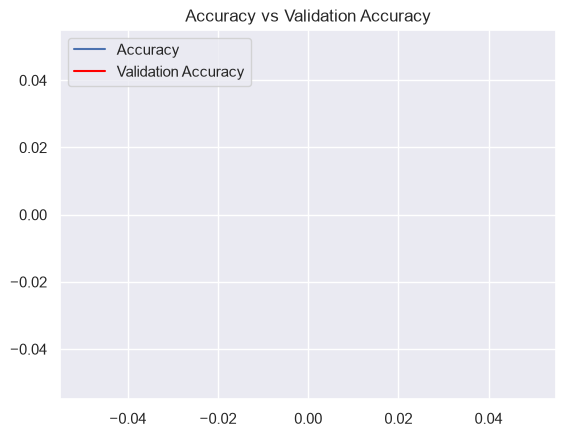

In [40]:
sns.set()

plt.plot(model_history['accuracy'], label="Accuracy")
plt.plot(model_history['val_accuracy'], c='red', label="Validation Accuracy")

plt.title("Accuracy vs Validation Accuracy")
plt.legend(loc="upper left")
plt.show()

#### Plotting Loss vs Validation Loss

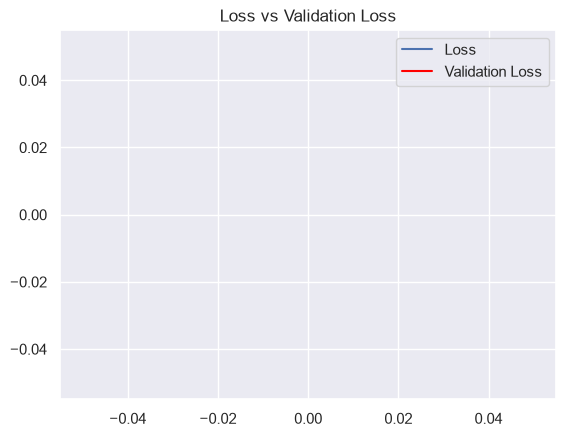

In [41]:
sns.set()

plt.plot(model_history['loss'], label="Loss")
plt.plot(model_history['val_loss'], c='red', label="Validation Loss")

plt.title("Loss vs Validation Loss")
plt.legend(loc="upper right")
plt.show()

### Loading the best checkpoint
Direct replacement for Keras's `model.load_weights()`: `torch.load(...)` deserialises the saved `state_dict`, and `model.load_state_dict(...)` copies those weights into the model instance in memory.
- **filepath:** path to the saved checkpoint (`model_checkpoint['filepath']`).
- **map_location:** device to load the tensors onto (`device`, defined earlier).
- **weights_only:** restricts deserialisation to tensors/primitives, safer than unpickling arbitrary objects.

In [42]:
# Loading the best model weights
best_checkpoint_path = Path(model_checkpoint['filepath'])
if best_checkpoint_path.is_file():
    model.load_state_dict(
        torch.load(
            best_checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    )
    model = model.to(device)
    print(f"Loaded {best_checkpoint_path}")
else:
    print(f"No checkpoint at {best_checkpoint_path} yet -- set RUN_TRAINING = True first.")

No checkpoint at artifacts\resnet50\best_model.pth yet -- set RUN_TRAINING = True first.


### Evaluating on the Test Set

In [43]:
# Setting model to evaluation mode
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for X, y in test_generator:

        # Moving data to device
        X = X.to(device)
        y = y.to(device)

        # Forward propagation
        outputs = model(X)

        # Calculate loss
        loss = criterion(outputs, y)
        test_loss += loss.item() * X.size(0)

        # Get predicted class
        _, predictions = torch.max(outputs, dim=1)

        # Calculate accuracy
        correct_predictions += (predictions == y).sum().item()
        total_predictions += y.size(0)

# Calculate average test loss
test_loss = test_loss / total_predictions

# Calculate test accuracy
test_accuracy = correct_predictions / total_predictions

print(f"The accuracy of our model on Testing Data is {(test_accuracy * 100):.3f}%")

The accuracy of our model on Testing Data is 50.000%


### Collecting predictions
Direct replacement for Keras's `model.predict_generator()`: iterate `test_generator` (a `DataLoader`) under `torch.no_grad()`, forward each batch through the model, and apply `torch.softmax()` to convert logits to probabilities.
- **test_generator:** the test-split `DataLoader` built above.
- **device:** where inference runs (`device`, defined earlier).
- No `steps`/`workers` arguments needed -- `DataLoader` already knows its own length and can parallelise loading via `num_workers`.

In [44]:
# Setting model to evaluation mode
model.eval()

predictions = []

with torch.no_grad():
    for X, _ in test_generator:

        # Moving data to device
        X = X.to(device)

        # Forward propagation
        outputs = model(X)

        # Convert logits into probabilities
        outputs = torch.softmax(outputs, dim=1)

        # Store predictions
        predictions.append(outputs.cpu())

# Concatenate predictions from all batches
predictions = torch.cat(predictions, dim=0)

In [45]:
print(predictions)

tensor([[0.4976, 0.5024],
        [0.4978, 0.5022],
        [0.4988, 0.5012],
        [0.4993, 0.5007],
        [0.4973, 0.5027],
        [0.4985, 0.5015],
        [0.4981, 0.5019],
        [0.4992, 0.5008],
        [0.4982, 0.5018],
        [0.4982, 0.5018],
        [0.4984, 0.5016],
        [0.4986, 0.5014],
        [0.4983, 0.5017],
        [0.4979, 0.5021],
        [0.4978, 0.5022],
        [0.4990, 0.5010],
        [0.4987, 0.5013],
        [0.4978, 0.5022],
        [0.4985, 0.5015],
        [0.4987, 0.5013],
        [0.4978, 0.5022],
        [0.4986, 0.5014],
        [0.4998, 0.5002],
        [0.4981, 0.5019],
        [0.4985, 0.5015],
        [0.4985, 0.5015],
        [0.4994, 0.5006],
        [0.4981, 0.5019],
        [0.4979, 0.5021],
        [0.4968, 0.5032],
        [0.4986, 0.5014],
        [0.4991, 0.5009],
        [0.4984, 0.5016],
        [0.4990, 0.5010],
        [0.4979, 0.5021],
        [0.4977, 0.5023],
        [0.4988, 0.5012],
        [0.4985, 0.5015],
        [0.4

In [46]:
# number of images in our testing dataset
len(test_generator.dataset)

200

In [47]:
# batch size for testing data generator
test_generator.batch_size

32

In [48]:
# store the predicted outcomes of our model

# Get the class with the highest probability for each sample
predicted_classes = np.argmax(predictions.numpy(), axis=1)

print(predicted_classes)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [49]:
# classes found in our testing data generator
test_true_labels = np.array(test_generator.dataset.targets)
print(test_true_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Metrics for our ResNet-50 Convolutional Neural Network

### Confustion Matrix

In [50]:
c_m = confusion_matrix(test_true_labels, predicted_classes)

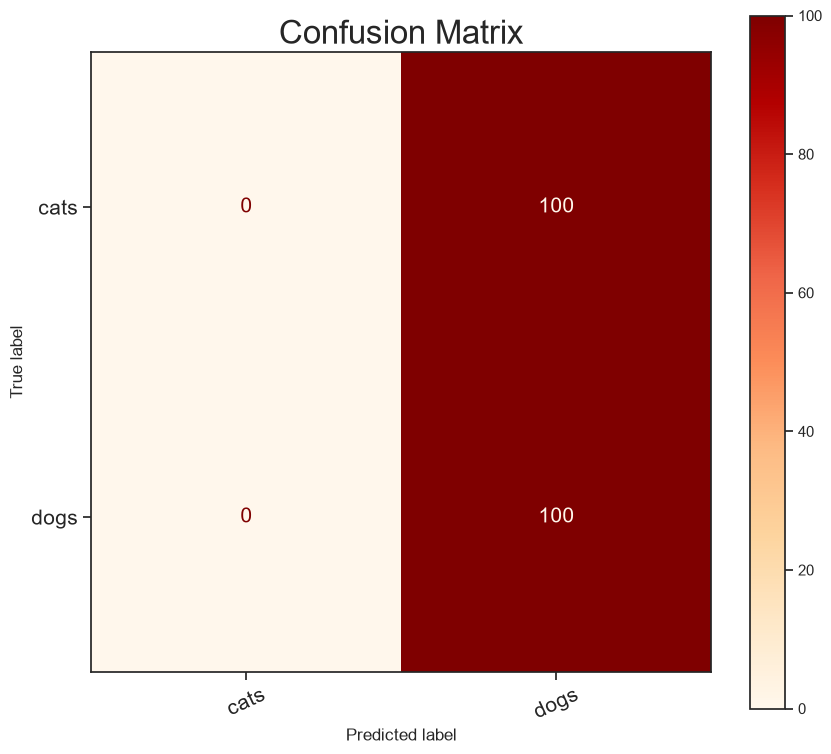

In [51]:
sns.set_style("ticks")

# Setting default size of the plot
# Setting default fontsize used in the plot
plt.rcParams['figure.figsize'] = (10.0, 9.0)
plt.rcParams['font.size'] = 15


# Implementing visualization of Confusion Matrix
display_c_m = ConfusionMatrixDisplay(c_m, display_labels=labels)


# Plotting Confusion Matrix
# Setting colour map to be used
display_c_m.plot(cmap='OrRd', xticks_rotation=25)
# Other possible options for colour map are:
# 'autumn_r', 'Blues', 'cool', 'Greens', 'Greys', 'PuRd', 'copper_r'


# Setting fontsize for xticks and yticks
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


# Giving name to the plot
plt.title('Confusion Matrix', fontsize=24)


# Saving plot
plt.savefig('artifacts/resnet50/confusion_matrix.png', transparent=True, dpi=500)

# Showing the plot
plt.show()

### Classification Report

In [52]:
print("Classification Report containes the following metrics:\n")
print(classification_report(test_true_labels, predicted_classes, target_names = labels))

Classification Report containes the following metrics:

              precision    recall  f1-score   support

        cats       0.00      0.00      0.00       100
        dogs       0.50      1.00      0.67       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



C:\Users\hamza\.virtualenvs\MLOps-Cats-Dogs-Pipeline-qxGGk82j\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hamza\.virtualenvs\MLOps-Cats-Dogs-Pipeline-qxGGk82j\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hamza\.virtualenvs\MLOps-Cats-Dogs-Pipeline-qxGGk82j\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [53]:
predictions_matrix = predictions.numpy()

### Precission-Recall Curve

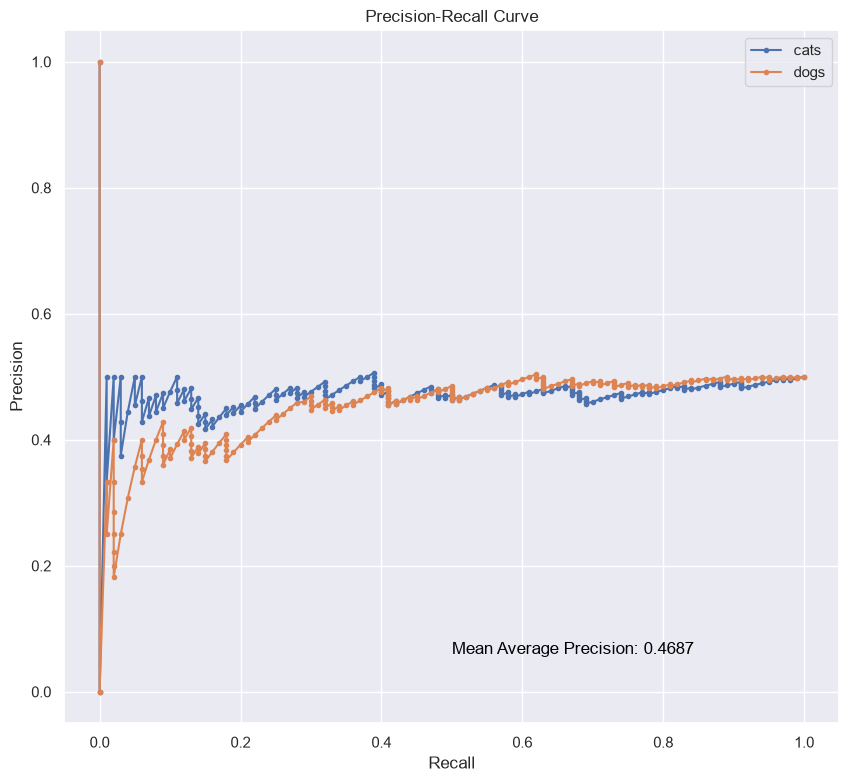

In [54]:
sns.set()

# Initialize empty lists to store precision, recall, and average precision for each class
precision_list = []
recall_list = []
average_precision_list = []

# Iterate over each class
for class_idx in range(predictions_matrix.shape[1]):
    # Get the predicted probabilities for the current class
    predictions_class = predictions_matrix[:, class_idx]

    # Convert the one-vs-all labels for the current class
    class_labels = (test_true_labels == class_idx).astype(int)

    # Calculate precision, recall, and average precision for the current class
    precision, recall, threshold = precision_recall_curve(class_labels, predictions_class)
    avg_precision = average_precision_score(class_labels, predictions_class)

    # Append the results to the respective lists
    precision_list.append(precision)
    recall_list.append(recall)
    average_precision_list.append(avg_precision)

    # Plot the precision-recall curve for the current class
    plt.plot(recall, precision, marker='.')

# Set the plot labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

# Show the legend with class names or indices
plt.legend(labels)

# Calculate the mean Precision-Recall score for multi-class classification
mean_average_precision = np.mean(average_precision_list)

# Add mean ROC-AUC score as a text annotation on the plot
plt.annotate(f"Mean Average Precision: {mean_average_precision:.4f}", xy=(0.5, 0.1), xycoords='axes fraction', fontsize=12, color='black')

# Show the plot
plt.show()

### ROC-AUC Curve

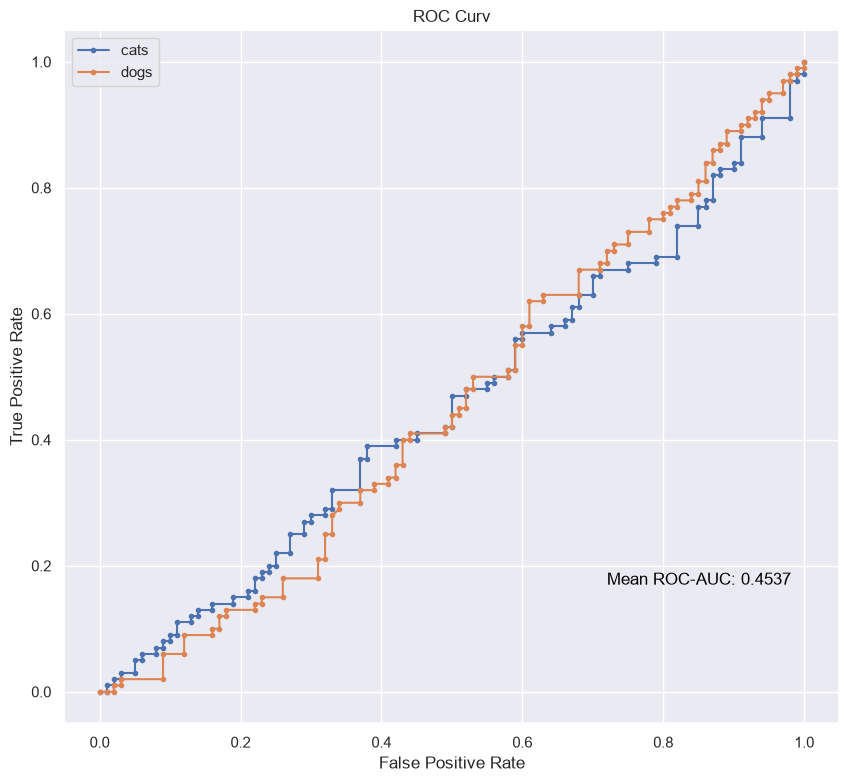

In [55]:
from sklearn.metrics import auc, roc_auc_score, roc_curve

sns.set()

# Initialize empty lists to store false positive rate, true positive rate, and AUC for each class
fpr_list = []
tpr_list = []
auc_list = []

# Iterate over each class
for class_idx in range(predictions_matrix.shape[1]):
    # Get the predicted probabilities for the current class
    predictions_class = predictions_matrix[:, class_idx]

    # Convert the one-vs-all labels for the current class
    class_labels = (test_true_labels == class_idx).astype(int)

    # Calculate false positive rate, true positive rate, and AUC for the current class
    fpr, tpr, _ = roc_curve(class_labels, predictions_class)
    roc_auc = auc(fpr, tpr)

    # Append the results to the respective lists
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    auc_list.append(roc_auc)

    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, marker='.')

# Set the plot labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curv")

# Show the legend with class names or indices
plt.legend(labels)

# Calculate the mean ROC-AUC score for multi-class classification
mean_roc_auc_score = np.mean(auc_list)

# Add mean ROC-AUC score as a text annotation on the plot
plt.annotate(f"Mean ROC-AUC: {mean_roc_auc_score:.4f}", xy=(0.7, 0.2), xycoords='axes fraction', fontsize=12, color='black')

# Show the plot
plt.show()

## Perform Prediction on Some Random Images

### Calling the model directly
PyTorch models are called directly as `model(input_tensor)` rather than through a `.predict()` method -- `predict_image()` below does exactly that, wrapped in `model.eval()` and `torch.no_grad()` so inference doesn't track gradients or apply dropout/batchnorm training behaviour.
- **input_tensor:** the preprocessed image, built with the same `build_evaluation_transform()` used for validation/test.
- **model:** the trained model in evaluation mode.
- **class_labels:** index-to-name mapping (`labels`) used to turn the predicted index into `"cats"`/`"dogs"`.

### numpy.argmax()
Returns the indices of the maximum values along an axis.
#### *Arguments*
- **a:** *array_like* <br> Input array.
- **axis:** *int, optional* <br> By default, the index is into the flattened array, otherwise along the specified axis.
- **out:** *array, optional* <br> If provided, the result will be inserted into this array. It should be of the appropriate shape and dtype.
- **keepdims:** *bool, optional* <br> If this is set to True, the axes which are reduced are left in the result as dimensions with size one. With this option, the result will broadcast correctly against the array.
#### *Returns*
- **index_array:** *ndarray of ints* <br> Array of indices into the array. It has the same shape as a.shape with the dimension along axis removed. If keepdims is set to True, then the size of axis will be 1 with the resulting array having same shape as a.shape.

In [56]:
def predict_image(image_path, model, class_labels):
    """
    This function takes an image path as an argument and predicts its class using the provided model.

    Arguments:
        image_path: Path, the path of the image.
        model: the trained PyTorch model used for prediction.
        class_labels: list of strings, containing the names of the classes.

    Returns:
        predicted_label: string, the predicted class label.
    """

    # read the image with the help of Pillow (this project's convention)
    image = Image.open(image_path).convert("RGB")

    # Preprocess exactly like evaluation data: resize, tensor, normalise, then
    # add the batch dimension the model expects (N, C, H, W).
    input_tensor = build_evaluation_transform(IMAGE_SIZE)(image).unsqueeze(0).to(device)

    # model.predict(...) is Keras-only -- nn.Module is called directly, in
    # eval mode with gradients disabled.
    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(input_tensor), dim=1)

    # Get the index of the predicted class with the highest probability
    predicted_class_index = int(probabilities.argmax(dim=1).item())

    # Get the corresponding class label
    predicted_label = class_labels[predicted_class_index]

    print("Predicted Label: ", predicted_label)
    print("Actual Label: ", image_path.parent.name)

    plt.imshow(image)
    plt.axis("off")
    plt.show()

Predicted Label:  dogs
Actual Label:  cats


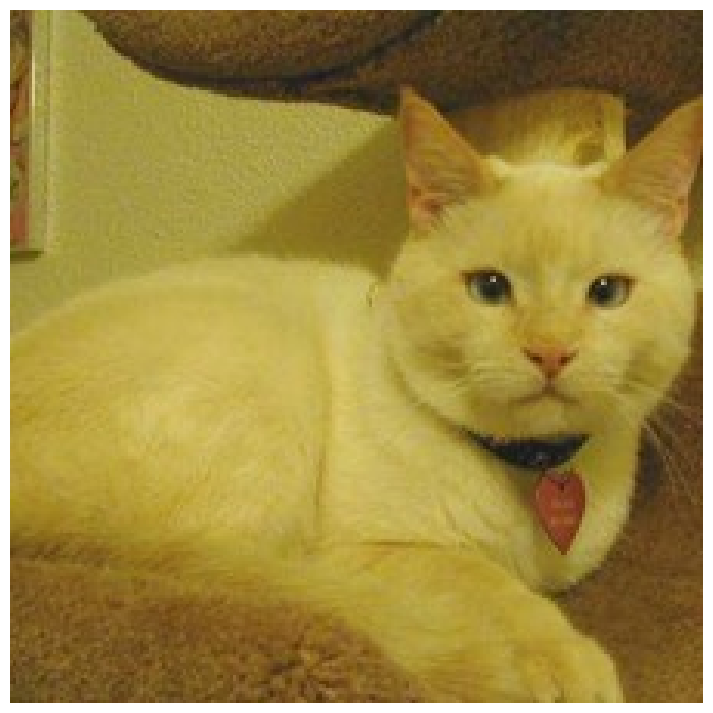




Predicted Label:  dogs
Actual Label:  cats


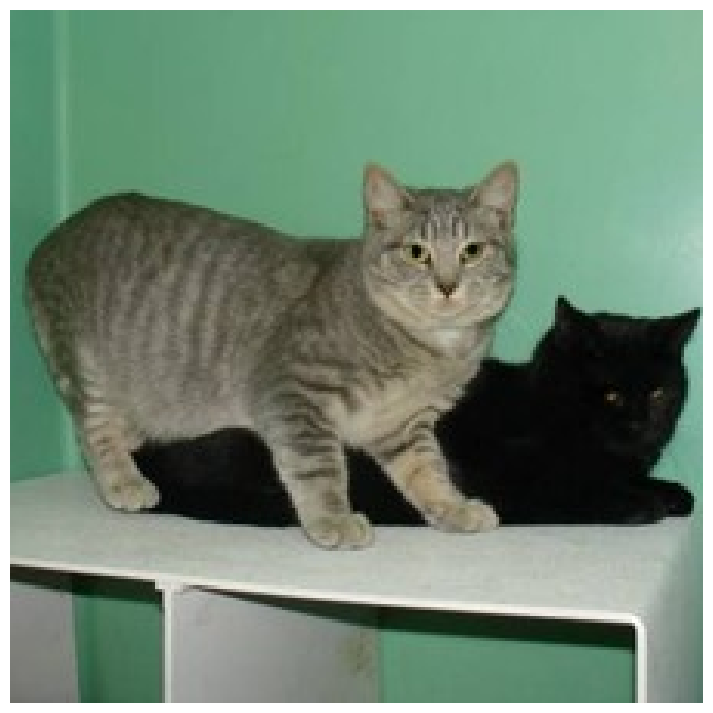




Predicted Label:  dogs
Actual Label:  cats


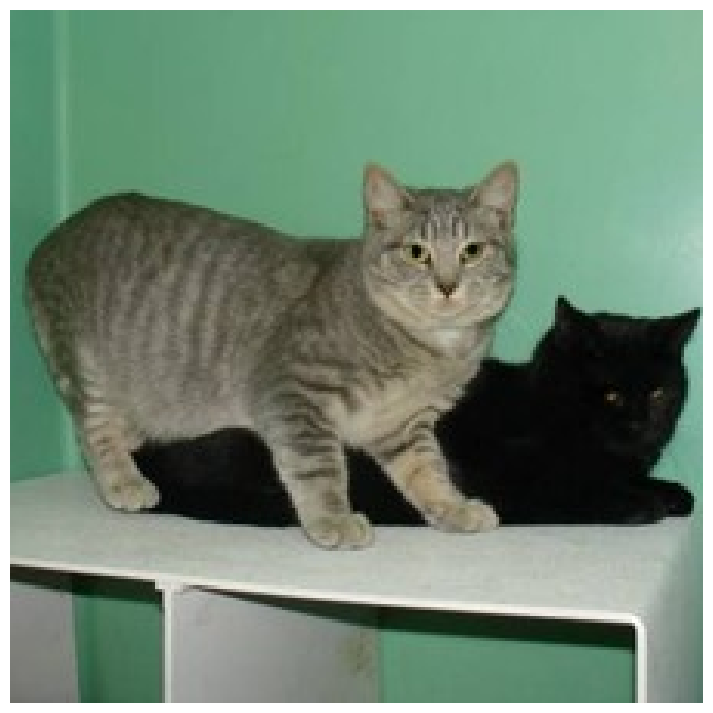

Predicted Label:  dogs
Actual Label:  dogs


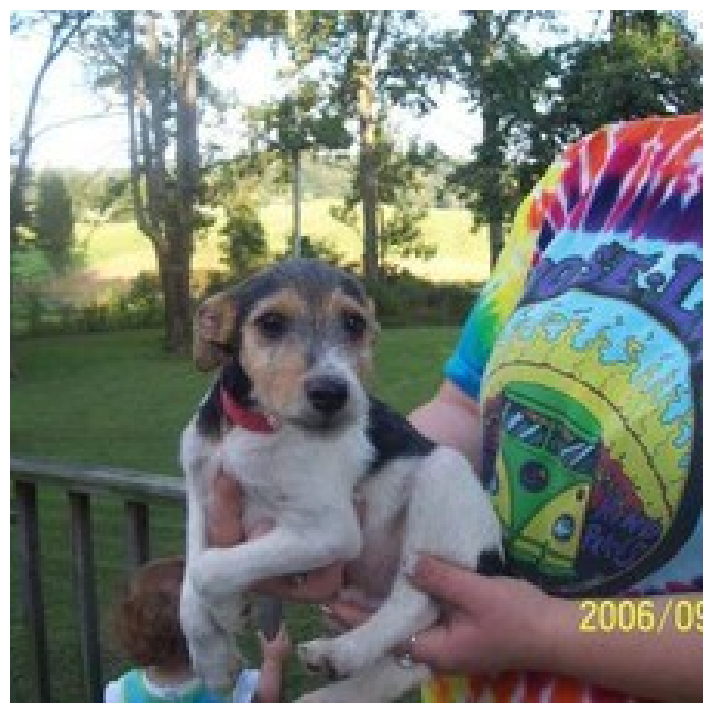




Predicted Label:  dogs
Actual Label:  dogs


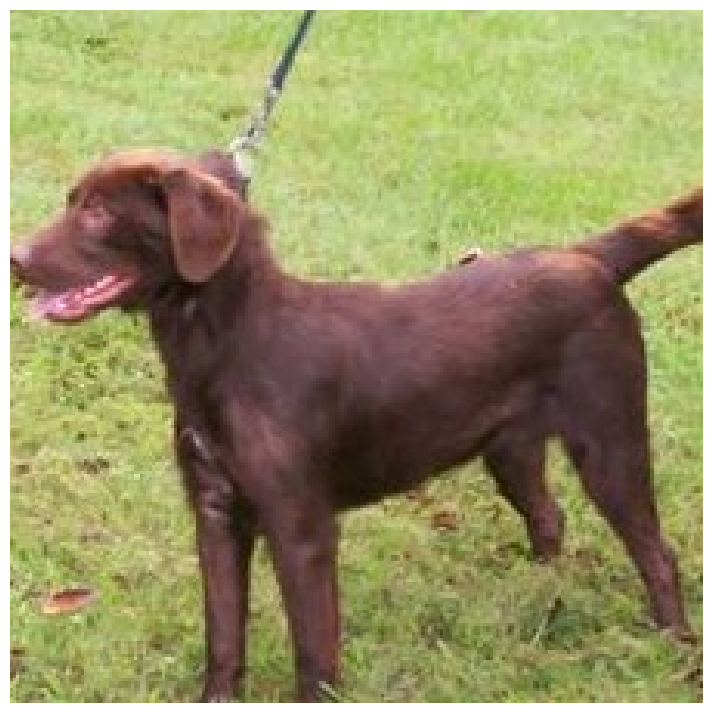




Predicted Label:  dogs
Actual Label:  dogs


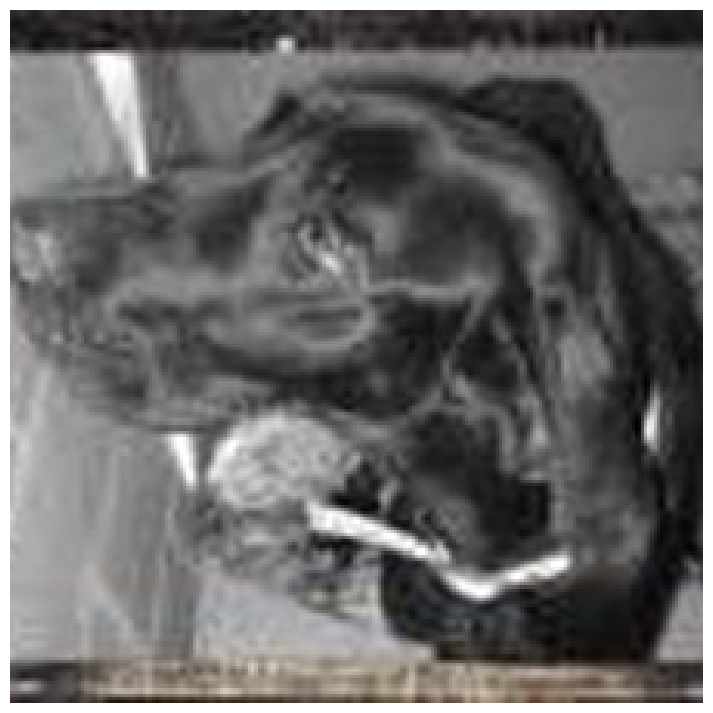

In [57]:
# list all class directories in the processed test split
if DATA_AVAILABLE:
    for class_directory in sorted(TEST_PATH.iterdir()):
        if not class_directory.is_dir():
            continue
        # pick 3 random images from each class of the test split
        for img_name in np.random.choice(os.listdir(class_directory), size=3):
            predict_image(class_directory / img_name, model, labels)
            print("\n\n")